<a href="https://colab.research.google.com/github/AbdelRayan/AutomaticSleepScoring/blob/main/Faranak/Complexity_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Set Up

## Libraries

In [5]:
# %%capture
# !pip install neurodsp
# !pip install emd
# !pip install tslearn
# !pip install dtaidistance
# !pip install sails
# !pip install specparam
# !pip install EntropyHub

In [6]:
import scipy
from scipy.io import loadmat
from scipy.interpolate import interp1d
from scipy.signal import hilbert
import matplotlib.pyplot as plt
from neurodsp.filt import filter_signal, filter_signal_fir, design_fir_filter
import emd
import numpy as np
import pandas as pd
from sklearn.preprocessing import Normalizer
from tqdm import tqdm
import plotly.express as px
from tslearn.clustering import TimeSeriesKMeans, KShape
from tslearn.metrics import dtw
from sklearn.decomposition import PCA, FastICA
from sklearn.preprocessing import StandardScaler
import copy
import sails
import requests
from io import BytesIO
from scipy.fftpack import fft
from scipy.signal import welch
from specparam import SpectralModel
from neurodsp.aperiodic import compute_fluctuations
from scipy.stats import zscore
from scipy.signal import savgol_filter
import EntropyHub as EH
import mne

##Colors

In [7]:
Red = '#d13838'
Blue = '#127be3'
DarkBlue = '#09217a'
LightBlue = '#9cd4ff'
Yellow = '#eff250'
Orange = '#faac11'
Purple = '#a170fd'

In [ ]:
def fragment_join(subject, night, type):
    base = f"C:/EEG_Data_stage/{subject}/iEEG/{type}"
    score_base = f"C:/EEG_Data_stage/{subject}/iEEG/scores"
    files = []
    scores = []
    for file in os.listdir(base):
        if f"night{night}" in file and ".vhdr" in file:
            files.append(os.path.join(base,file))
            scores.append(os.path.join(score_base,file.replace(".vhdr", "_hypnogram.npy")))
    return files, scores  

# Data

In [8]:
# raw = mne.io.read_raw_brainvision("D:/converted_sleep_data/TLLTR/2/combined_nights/night2.vhdr")
files = [
    "C:/EEG_Data_stage/7/iEEG/converted/7_night1_01.vhdr",
    "C:/EEG_Data_stage/7/iEEG/converted/7_night1_02.vhdr",
    "C:/EEG_Data_stage/7/iEEG/converted/7_night1_03.vhdr"
]


raw_list = [mne.io.read_raw_brainvision(f, preload=True) for f in files]

raw = mne.concatenate_raws(raw_list)
hpc_data = raw.get_data(picks='Oz-Cz')[0]
hpc_tag = 'Oz-Cz'
hpc_data = np.ravel(hpc_data)

scores_files = [
    "C:/EEG_Data_stage/7/iEEG/converted/scores/7_night1_01_hypnogram.npy",
    "C:/EEG_Data_stage/7/iEEG/converted/scores/7_night1_02_hypnogram.npy",
    "C:/EEG_Data_stage/7/iEEG/converted/scores/7_night1_03_hypnogram.npy"
]
score_list = [np.load(f) for f in scores_files]
states = np.concatenate(score_list)

Extracting parameters from C:/EEG_Data_stage/7/iEEG/converted/7_night1_01.vhdr...
Setting channel info structure...
Reading 0 ... 2256111  =      0.000 ...  9024.444 secs...
Extracting parameters from C:/EEG_Data_stage/7/iEEG/converted/7_night1_02.vhdr...
Setting channel info structure...
Reading 0 ... 2700031  =      0.000 ... 10800.124 secs...
Extracting parameters from C:/EEG_Data_stage/7/iEEG/converted/7_night1_03.vhdr...
Setting channel info structure...
Reading 0 ... 1990559  =      0.000 ...  7962.236 secs...


In [9]:
pfc_data = raw.get_data(picks='C3-Cz')[0]
pfc_tag = 'C3-Cz'
pfc_data = np.ravel(pfc_data)

In [10]:
len(pfc_data)

6946704

In [11]:
lfp_PFC = np.ravel(pfc_data)  # flatten in case it's 2D
sleep_states = states.flatten() 

In [12]:
for idx in range(len(sleep_states)):
    if sleep_states[idx] == 0:
        print(idx)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
77
82
93
94
95
96
97
98
99
101
102
103
104
105
106
107
108
109
110
111
112
113
116
118
119
120
121
122
123
126
127
129
130
131
167
176
228
229
242
243
309
313
431
642
643
656
657
990
991
992
993
995
1011
1149
1150
1296
1297
1298
1400
1405
1406
1407
1413
1414
1717
1718
1719
1720
1722
1723
1724
1726
1751
1754
1755
1756
1757
1758
1880
1882
1885
1886
1887
1888
1889
1890
1951
2103
2104
2211
2212
2213
2214
2215
2216
2217
2218
2219
2220
2221
2222
2223
2224
2225
2226
2227
2228
2229
2230
2231
2232
2233
2234
2235
2236
2237
2238
2239
2240
2241
2242
2243
2244
2245
2246
2247
2248
2249
2250
2251
2252
2253
2254
2255
2256
2257
2258
2259
2260
2261
2262
2263
2264
2265
2266
2267
2268
2269
2270
2271
2272
2273
2274
2275
2276
2277
2278
2279
2280
2281
2282
2283
2284
2285
2286
2287
2288
2289
2290
2

##OS Basic

# 1. RGS14: Results for Windowing (4s Windows)

In [13]:
fs = 250
window_size = 10 * fs
step_size = window_size  # In case we wanted overlap later.

## Aperiodic Fit

In [ ]:
num_windows = len(lfp_PFC) // window_size
time_stamps = np.arange(num_windows) * 4

aperiodic_exponents = []

for i in range(num_windows):
    start, end = i * window_size, (i + 1) * window_size
    window_data = lfp_PFC[start:end]

    freqs, psd = welch(window_data, fs=fs, nperseg=window_size)

    mask = (freqs <= 100)
    freqs, psd = freqs[mask], psd[mask]

    fm = SpectralModel(min_peak_height=0.05, aperiodic_mode='knee', verbose=False)
    fm.fit(freqs, psd)

    aperiodic_exponents.append(fm.get_params('aperiodic')[1])

aperiodic_exponents = np.array(aperiodic_exponents)

# Thresholding to remove outliers
threshold_min = np.percentile(aperiodic_exponents, 2)
threshold_max = np.percentile(aperiodic_exponents, 98)
valid_indices = (aperiodic_exponents >= threshold_min) & (aperiodic_exponents <= threshold_max)

filtered_exponents = aperiodic_exponents[valid_indices]
filtered_timestamps = time_stamps[valid_indices]

#filtered_exponents_z = (filtered_exponents - np.mean(filtered_exponents)) / np.std(filtered_exponents)
window_length = 11 if len(filtered_exponents) >= 11 else len(filtered_exponents) | 1  # ensure it's odd
polyorder = 4

smoothed_exponents = savgol_filter(filtered_exponents, window_length=window_length, polyorder=polyorder)
normalized_exponents = 2 * ((smoothed_exponents - min(smoothed_exponents)) /(max(smoothed_exponents) - min(smoothed_exponents))) - 1

plt.figure(figsize=(18, 5))
plt.plot(filtered_timestamps, normalized_exponents, marker='.', linestyle='-', color=DarkBlue)
plt.xlabel('Time (s)')
plt.ylabel('Aperiodic Exponent')
plt.title('Normalized Aperiodic Fit Over Time (With Threshold)')
#plt.axhline(0, color='r', linestyle='--', label='Mean')
#plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("Aperiodic_fit.svg", format='svg')
plt.show()

## DFA

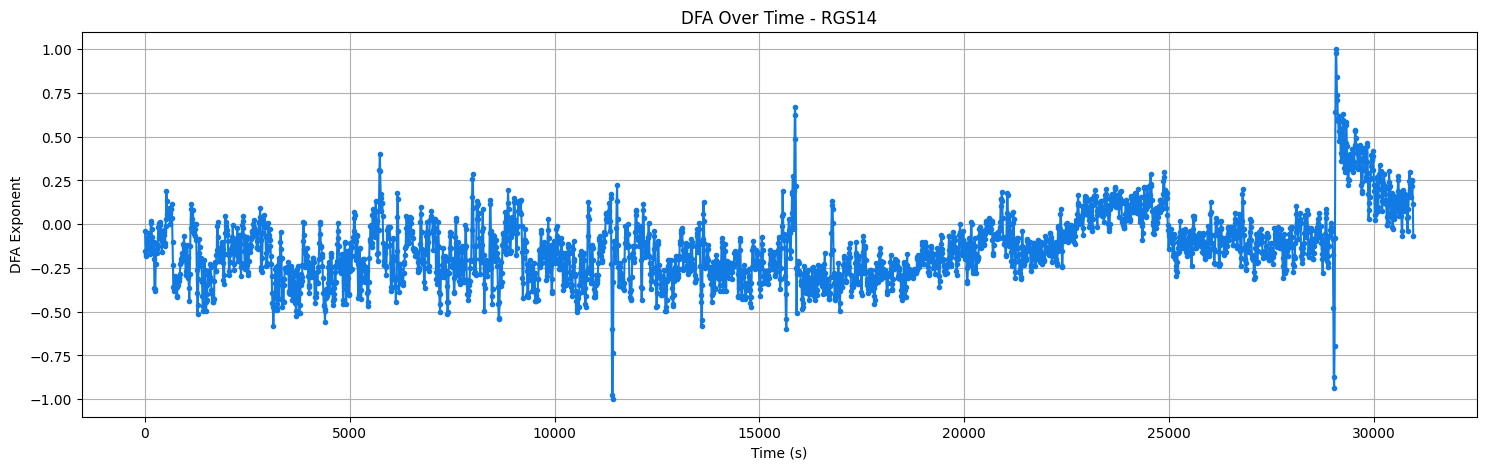

In [17]:
num_windows = (len(lfp_PFC) - window_size) // step_size + 1

dfa_exponents = []
time_stamps = []

for i in range(num_windows):
    start = i * step_size
    end = start + window_size
    segment = lfp_PFC[start:end]

    _, _, exp_window = compute_fluctuations(segment, fs, n_scales=10,
                                            min_scale=0.05, max_scale=4.0)

    dfa_exponents.append(exp_window)
    time_stamps.append((start + end) / 2 / fs)

dfa_exponents = np.array(dfa_exponents)
window_length = 11 if len(dfa_exponents) >= 11 else len(dfa_exponents) | 1  # ensure it's odd
polyorder = 4

smoothed_dfa = savgol_filter(dfa_exponents, window_length=window_length, polyorder=polyorder)
normalized_dfa = 2 * ((smoothed_dfa - min(smoothed_dfa)) /(max(smoothed_dfa) - min(smoothed_dfa))) - 1
plt.figure(figsize=(18, 5))
plt.plot(time_stamps, normalized_dfa, marker='.', linestyle='-', color=Blue)
plt.xlabel('Time (s)')
plt.ylabel('DFA Exponent')
plt.title('DFA Over Time - RGS14')
plt.grid()
plt.savefig("DFA_over_time.svg", format='svg')
plt.show()

## MSE

 . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .

C:\Users\timmi\miniconda3\Lib\site-packages\EntropyHub\_IncrEn.py:69: RuntimeWarning: divide by zero encountered in divide
  Qk = np.minimum(R, np.floor(abs(Vk)*R/Temp))


 . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .

C:\Users\timmi\miniconda3\Lib\site-packages\EntropyHub\_IncrEn.py:69: RuntimeWarning: invalid value encountered in divide
  Qk = np.minimum(R, np.floor(abs(Vk)*R/Temp))


 . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .

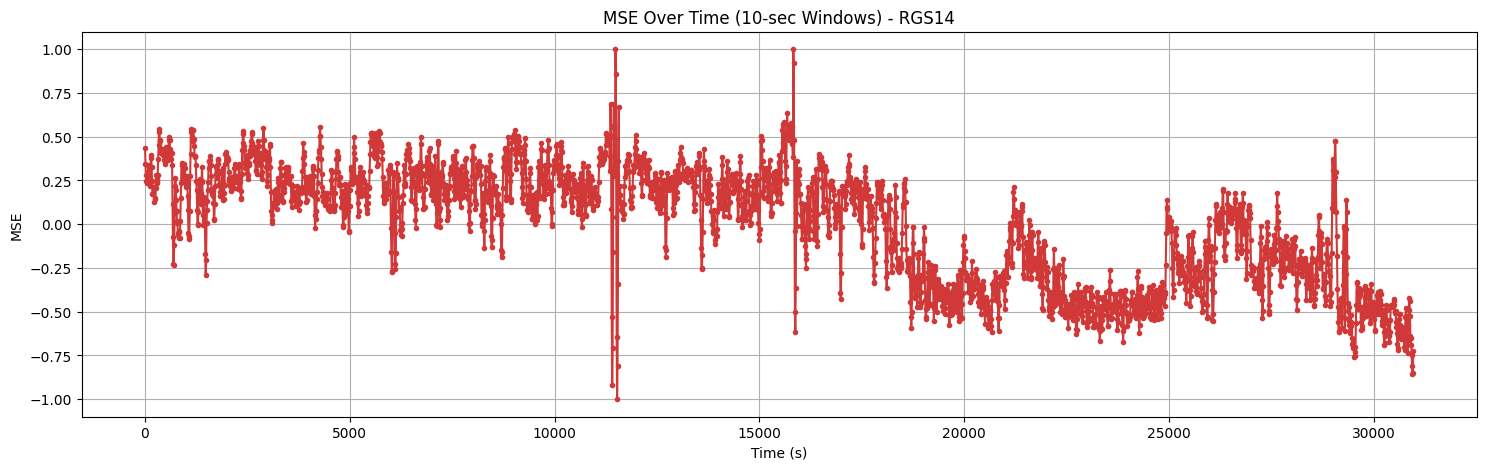

In [18]:
Mobj = EH.MSobject('IncrEn', m=2, R=3, Norm=True)

num_windows = (len(lfp_PFC) - window_size) // step_size + 1

mse_values = []
time_stamps_mse = []

for i in range(num_windows):
    start = i * step_size
    end = start + window_size
    segment = lfp_PFC[start:end]

    MSx, _ = EH.MSEn(segment, Mobj, Scales=2, Methodx='modified')

    mse_values.append(np.mean(MSx))
    time_stamps_mse.append((start + end) / 2 / fs)

mse_values = np.array(mse_values)
time_stamps_mse = np.array(time_stamps_mse)
window_length = 11 if len(mse_values) >= 11 else len(mse_values) | 1  # ensure it's odd
polyorder = 4

smoothed_mse = savgol_filter(mse_values, window_length=window_length, polyorder=polyorder)
normalized_mse = 2 * ((smoothed_mse - min(smoothed_mse)) /(max(smoothed_mse) - min(smoothed_mse))) - 1

plt.figure(figsize=(18, 5))
plt.plot(time_stamps_mse, normalized_mse, marker='.', linestyle='-', color=Red)
plt.xlabel('Time (s)')
plt.ylabel('MSE')
plt.title('MSE Over Time (10-sec Windows) - RGS14')
plt.grid()
plt.savefig("MSE_10s.svg", format='svg')
plt.show()

## Final Plot

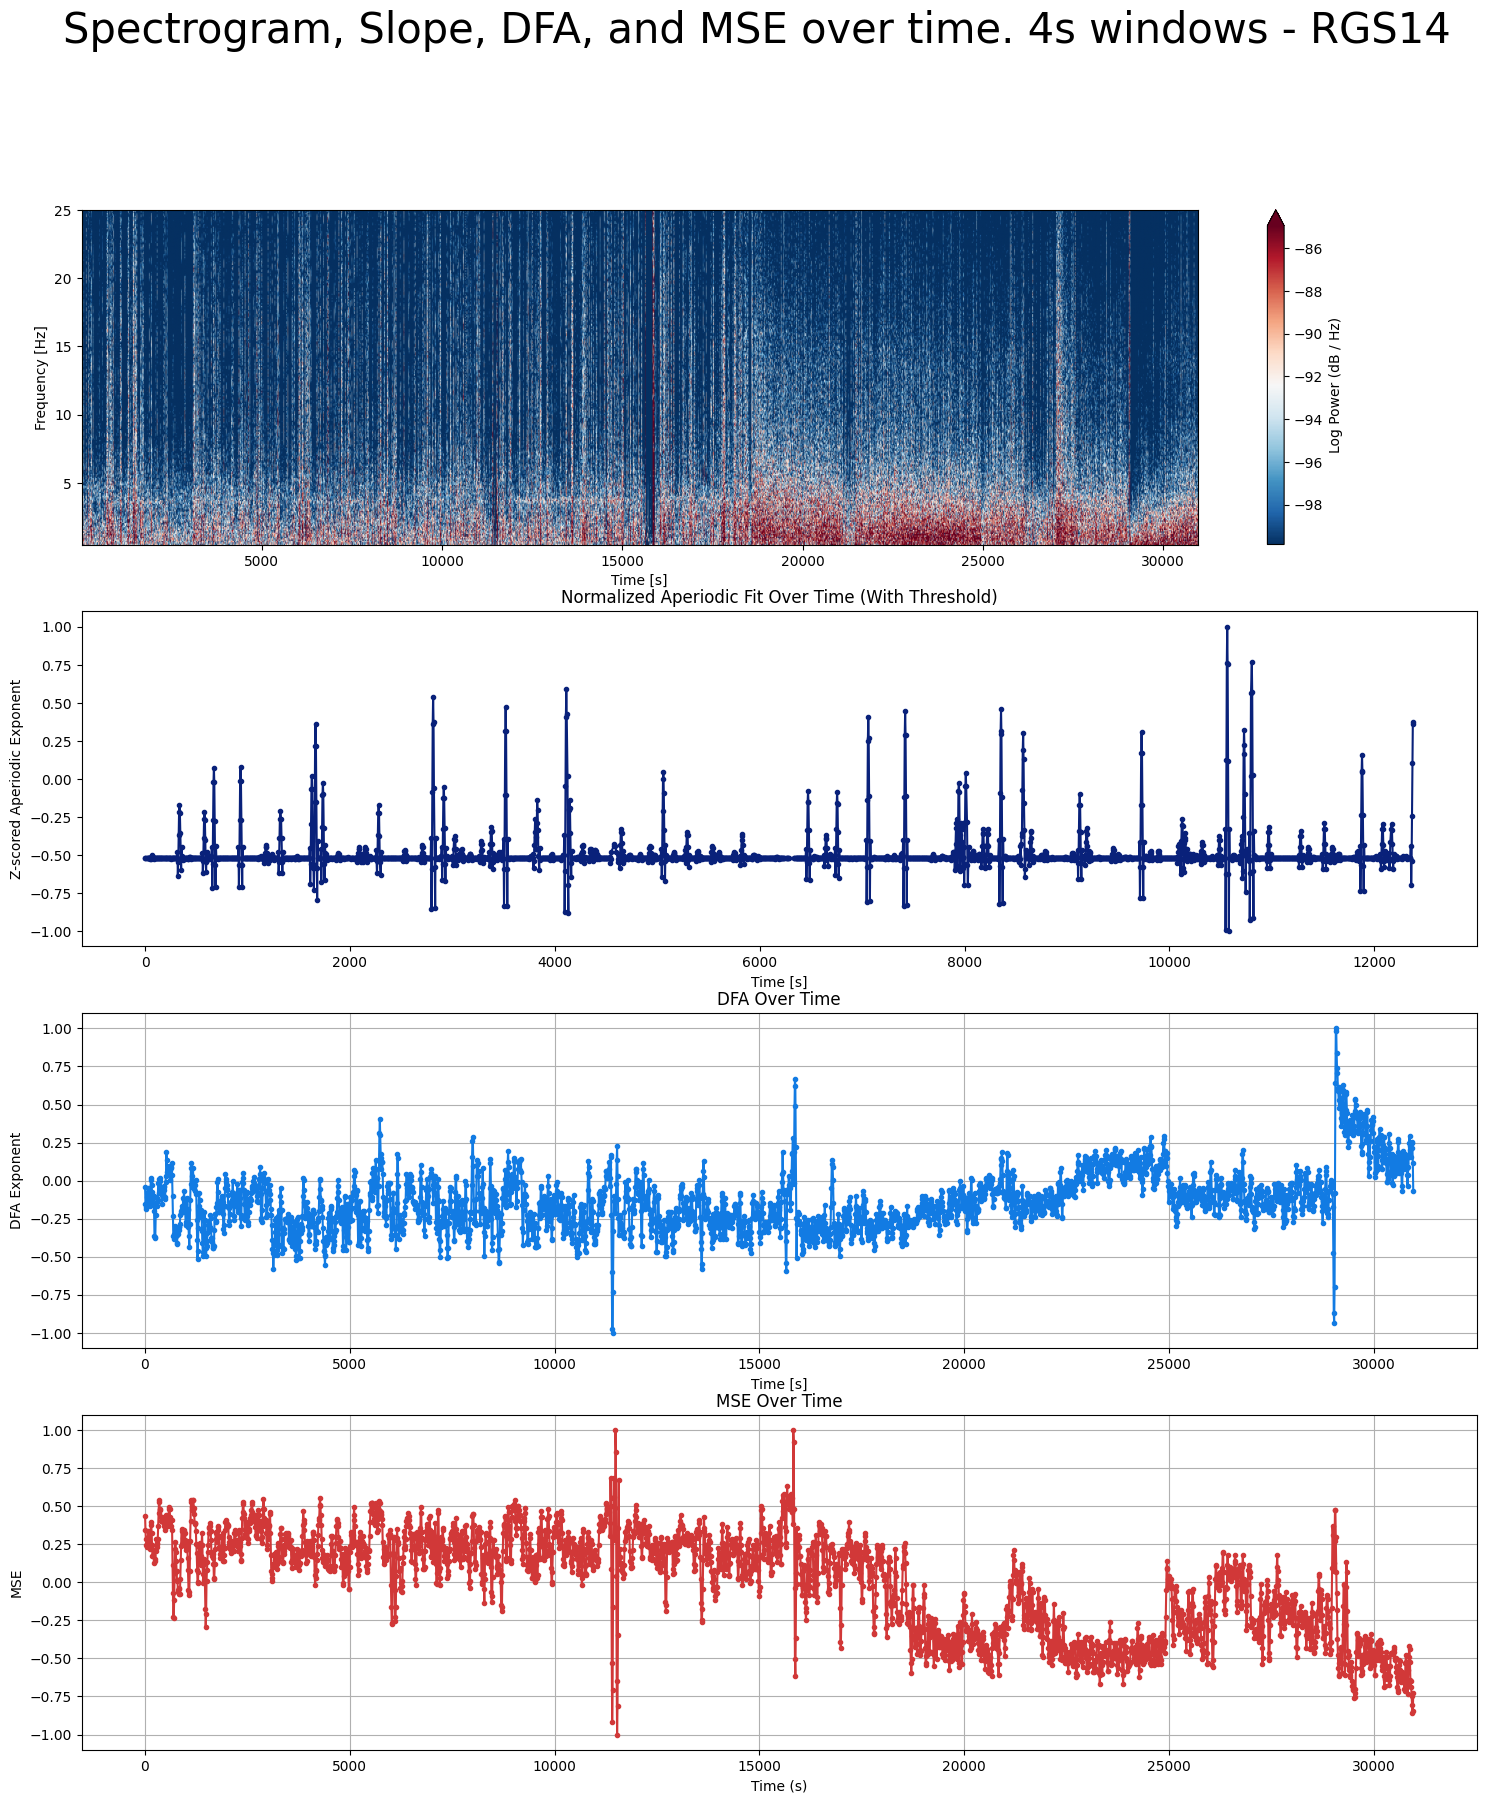

In [19]:
# SPECTROGRAM
nperseg = int(10 * fs)      # Window Size
fmin, fmax = 0.5, 25

# Create Plot
fig, axs = plt.subplots(4, 1, figsize=(18, 20))
fig.suptitle('Spectrogram, Slope, DFA, and MSE over time. 4s windows - RGS14', fontsize=30)

Pxx, freqs, bins, im = axs[0].specgram(lfp_PFC, NFFT=nperseg, Fs=fs, cmap="RdBu_r", scale="dB")

# Frequency (0.5 Hz ≤ f ≤ 25 Hz)
freq_mask = (freqs >= fmin) & (freqs <= fmax)
freqs = freqs[freq_mask]
Pxx = Pxx[freq_mask, :]

vmin, vmax = np.percentile(10 * np.log10(Pxx + 1e-10), [10, 98])
im.set_clim(vmin, vmax)

axs[0].set_ylabel("Frequency [Hz]")
axs[0].set_xlabel("Time [s]")
cbar = fig.colorbar(im, ax=axs[0], extend='max', label="Log Power (dB / Hz)")
axs[0].set_ylim(fmin, fmax)


# SLOPE
axs[1].plot(filtered_timestamps, normalized_exponents, marker='.', linestyle='-', color=DarkBlue)
axs[1].set_xlabel('Time [s]')
axs[1].set_ylabel('Z-scored Aperiodic Exponent')
axs[1].set_title('Normalized Aperiodic Fit Over Time (With Threshold)')
#axs[1].axhline(0, color='r', linestyle='--', label='Mean')
#axs[1].legend()

# DFA
axs[2].plot(time_stamps, normalized_dfa, marker='.', linestyle='-', color=Blue)
axs[2].set_xlabel('Time [s]')
axs[2].set_ylabel('DFA Exponent')
axs[2].set_title('DFA Over Time')
axs[2].grid()

axs[3].plot(time_stamps_mse, normalized_mse, marker='.', linestyle='-', color=Red)
axs[3].set_xlabel('Time (s)')
axs[3].set_ylabel('MSE')
axs[3].set_title('MSE Over Time')
axs[3].grid()
plt.savefig("combined.svg", format='svg')
plt.show()

# 2. RGS14: Results for Epochs
-Not Suitable.

In [20]:
def find_all_state_epochs(state_array):
    """
    Returns a list of (start_sample_idx, end_sample_idx, state) tuples.
    Assumes each element in state_array represents 1 second of signal.
    """
    epochs = []
    start_idx = 0

    for i in range(1, len(state_array)):
        if state_array[i] != state_array[i - 1]:
            end_idx = i - 1
            state = state_array[start_idx]
            epochs.append((start_idx, end_idx, state))
            start_idx = i

    # Add last epoch
    epochs.append((start_idx, len(state_array) - 1, state_array[start_idx]))
    return epochs

In [21]:
samples_per_state = fs  # If state_array is per second

aperiodic_exponents = []
state_labels = []
epoch_times = []

state_epochs = find_all_state_epochs(sleep_states)

for idx, (start_sec, end_sec, state) in enumerate(state_epochs):
    # Convert to sample indices
    start_sample = start_sec * samples_per_state
    end_sample = (end_sec + 1) * samples_per_state  # +1 to include the full last second

    epoch_signal = lfp_PFC[start_sample:end_sample]

    # Skip if too short
    if len(epoch_signal) < 2 * fs:
        continue

    # Compute PSD
    freqs, psd = welch(epoch_signal, fs=fs, nperseg=4096)
    freqs, psd = freqs[freqs <= 100], psd[freqs <= 100]

    # Fit aperiodic component
    try:
        fm = SpectralModel(min_peak_height=0.05, aperiodic_mode='knee', verbose=False)
        fm.fit(freqs, psd)
        exponent = fm.get_params('aperiodic')[1]
        aperiodic_exponents.append(exponent)
        state_labels.append(state)
        epoch_times.append(idx)
    except Exception as e:
        print(f"Skipping epoch {idx} due to error: {e}")

C:\Users\timmi\AppData\Local\Temp\ipykernel_11708\3533767935.py:21: UserWarning: nperseg=4096 is greater than signal length max(len(x), len(y)) = 500, using nperseg = 500
  freqs, psd = welch(epoch_signal, fs=fs, nperseg=4096)
C:\Users\timmi\AppData\Local\Temp\ipykernel_11708\3533767935.py:21: UserWarning: nperseg=4096 is greater than signal length max(len(x), len(y)) = 500, using nperseg = 500
  freqs, psd = welch(epoch_signal, fs=fs, nperseg=4096)
C:\Users\timmi\AppData\Local\Temp\ipykernel_11708\3533767935.py:21: UserWarning: nperseg=4096 is greater than signal length max(len(x), len(y)) = 500, using nperseg = 500
  freqs, psd = welch(epoch_signal, fs=fs, nperseg=4096)
C:\Users\timmi\AppData\Local\Temp\ipykernel_11708\3533767935.py:21: UserWarning: nperseg=4096 is greater than signal length max(len(x), len(y)) = 1250, using nperseg = 1250
  freqs, psd = welch(epoch_signal, fs=fs, nperseg=4096)
C:\Users\timmi\AppData\Local\Temp\ipykernel_11708\3533767935.py:21: UserWarning: nperseg=4

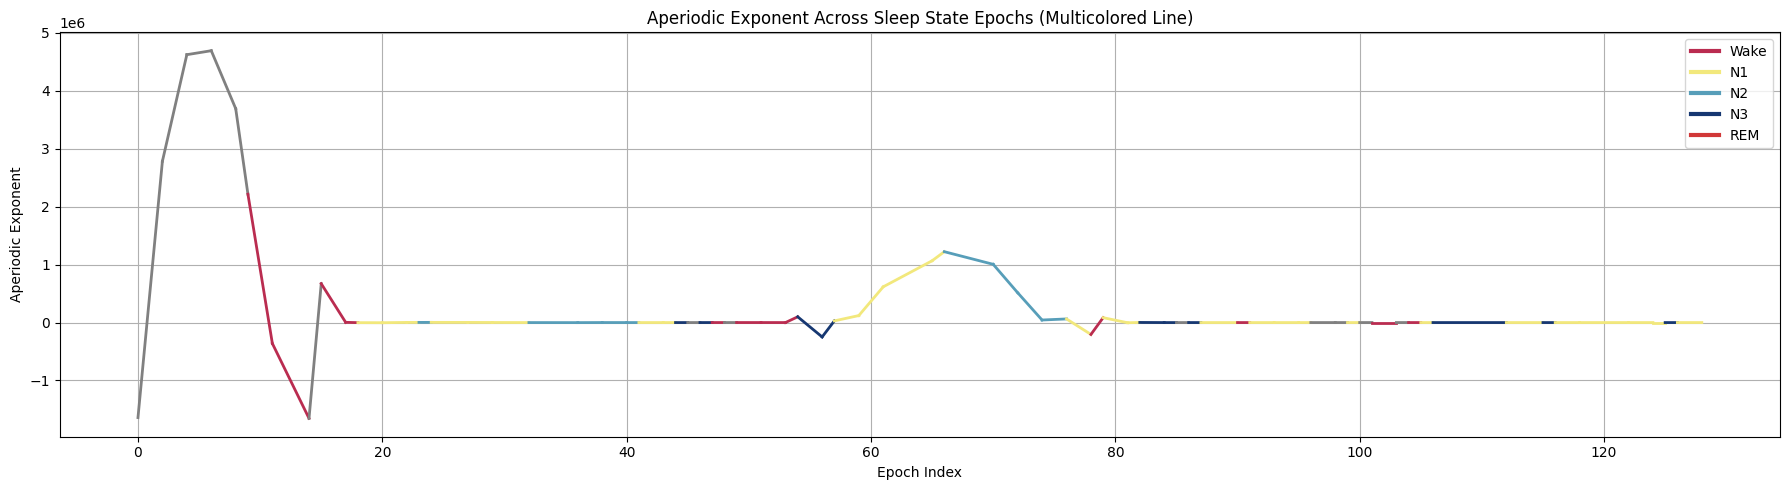

In [22]:
aperiodic_exponents = np.array(aperiodic_exponents)
state_labels = np.array(state_labels)
epoch_times = np.array(epoch_times)

# Remove outliers
threshold_min = np.percentile(aperiodic_exponents, 2)
threshold_max = np.percentile(aperiodic_exponents, 98)
valid = (aperiodic_exponents >= threshold_min) & (aperiodic_exponents <= threshold_max)

#filtered_exponents = aperiodic_exponents[valid]
#filtered_states = state_labels[valid]
#filtered_times = epoch_times[valid]

# Z-score the filtered exponents
#z_exponents = (filtered_exponents - np.mean(filtered_exponents)) / np.std(filtered_exponents)
#filtered_exponents_z = (filtered_exponents - np.mean(filtered_exponents)) / np.std(filtered_exponents)
window_length = 11 if len(aperiodic_exponents) >= 11 else len(aperiodic_exponents) | 1  # ensure it's odd
polyorder = 4

smoothed_exponents = savgol_filter(aperiodic_exponents, window_length=window_length, polyorder=polyorder)

# Color mapping for states
state_map = {1: '#BA2C50', 2: '#F2E87C', 3: '#579EB9', 4: '#163771', 5:Red}
state_names = {1: 'Wake', 2: 'N1', 3: 'N2', 4: 'N3', 5: 'REM'}
plt.figure(figsize=(18, 5))


# Plot each line segment with its state color
for i in range(min(len(epoch_times), len(smoothed_exponents)) - 1):
    x = [epoch_times[i], epoch_times[i + 1]]
    y = [smoothed_exponents[i], smoothed_exponents[i + 1]]
    state = state_labels[i]
    color = state_map.get(state, 'gray')
    plt.plot(x, y, color=color, linewidth=2)
# Mean line
#plt.axhline(0, color='red', linestyle='--', label='Mean')

plt.xlabel('Epoch Index')
plt.ylabel('Aperiodic Exponent')
plt.title('Aperiodic Exponent Across Sleep State Epochs (Multicolored Line)')
plt.grid(True)

# Legend for states
legend_elements = [plt.Line2D([0], [0], color=state_map[s], lw=3, label=state_names[s]) for s in state_map]
#legend_elements.append(plt.Line2D([0], [0], linestyle='--', color='red', label='Mean'))

plt.legend(handles=legend_elements, loc='upper right')
plt.tight_layout()
plt.savefig("Aperiodic_exp_across_sleep_States.svg", format='svg')
plt.show()

In [23]:
# First, find the epochs
epochs = find_all_state_epochs(sleep_states)  # state_array has 1 sample/sec

dfa_exponents = []
epoch_times = []
epoch_labels = []

for start_sec, end_sec, state in epochs:
    start_sample = start_sec * fs
    end_sample = (end_sec + 1) * fs  # +1 to include the last second

    segment = lfp_PFC[start_sample:end_sample]

    #if len(segment) < fs * 2:  # skip very short epochs (e.g. <5 sec)
     #   continue

    try:
        _, _, exp_epoch = compute_fluctuations(segment, fs, n_scales=10,
                                               min_scale=0.05, max_scale=4.0)
        dfa_exponents.append(exp_epoch)
        epoch_times.append((start_sample + end_sample) / 2 / fs)
        epoch_labels.append(state)
    except Exception as e:
        print(f"Skipped epoch due to error: {e}")
        continue

C:\Users\timmi\miniconda3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\timmi\miniconda3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


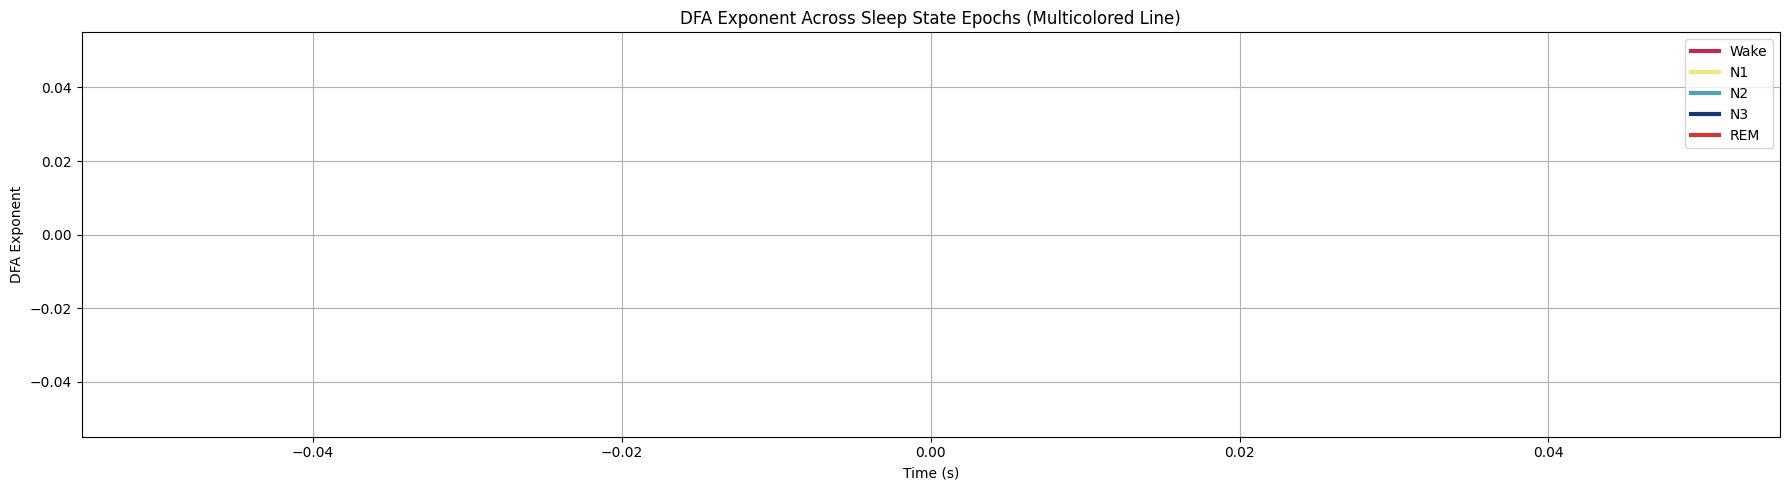

In [24]:
plt.figure(figsize=(18, 5))

window_length = 11 if len(dfa_exponents) >= 11 else len(dfa_exponents) | 1  # ensure it's odd
polyorder = 4

dfa_smoothed_exponents = savgol_filter(dfa_exponents, window_length=window_length, polyorder=polyorder)

# Plot each line segment with its state color
for i in range(len(epoch_times) - 1):
    x = [epoch_times[i], epoch_times[i + 1]]
    y = [dfa_smoothed_exponents[i], dfa_smoothed_exponents[i + 1]]
    state = epoch_labels[i]
    color = state_map.get(state, 'gray')
    plt.plot(x, y, color=color, linewidth=2)


plt.xlabel('Time (s)')
plt.ylabel('DFA Exponent')
plt.title('DFA Exponent Across Sleep State Epochs (Multicolored Line)')
plt.grid(True)

# Legend for states
legend_elements = [plt.Line2D([0], [0], color=state_map[s], lw=3, label=state_names[s]) for s in state_map]

plt.legend(handles=legend_elements, loc='upper right')
plt.tight_layout()
plt.show()

In [25]:
# Create the Multiscale Entropy object
Mobj = EH.MSobject('IncrEn', m=2, R=3, Norm=True)

# Get the sleep stage-defined epochs
epochs = find_all_state_epochs(sleep_states)

mse_values_epoch = []
epoch_times_mse = []
epoch_labels_mse = []

for start_sec, end_sec, state in epochs:
    start_sample = start_sec * fs
    end_sample = (end_sec + 1) * fs  # include the end

    segment = lfp_PFC[start_sample:end_sample]

    # Skip very short segments (e.g., <2*Scale)
    #if len(segment) < fs * 2:
    #   continue

    try:
        MSx, _ = EH.MSEn(segment, Mobj, Scales=2, Methodx='modified')
        mse_values_epoch.append(np.mean(MSx))
        epoch_times_mse.append((start_sample + end_sample) / 2 / fs)
        epoch_labels_mse.append(state)
    except Exception as e:
        print(f"Skipped epoch due to error: {e}")
        continue

 . .

C:\Users\timmi\miniconda3\Lib\site-packages\EntropyHub\_IncrEn.py:69: RuntimeWarning: divide by zero encountered in divide
  Qk = np.minimum(R, np.floor(abs(Vk)*R/Temp))


 . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .

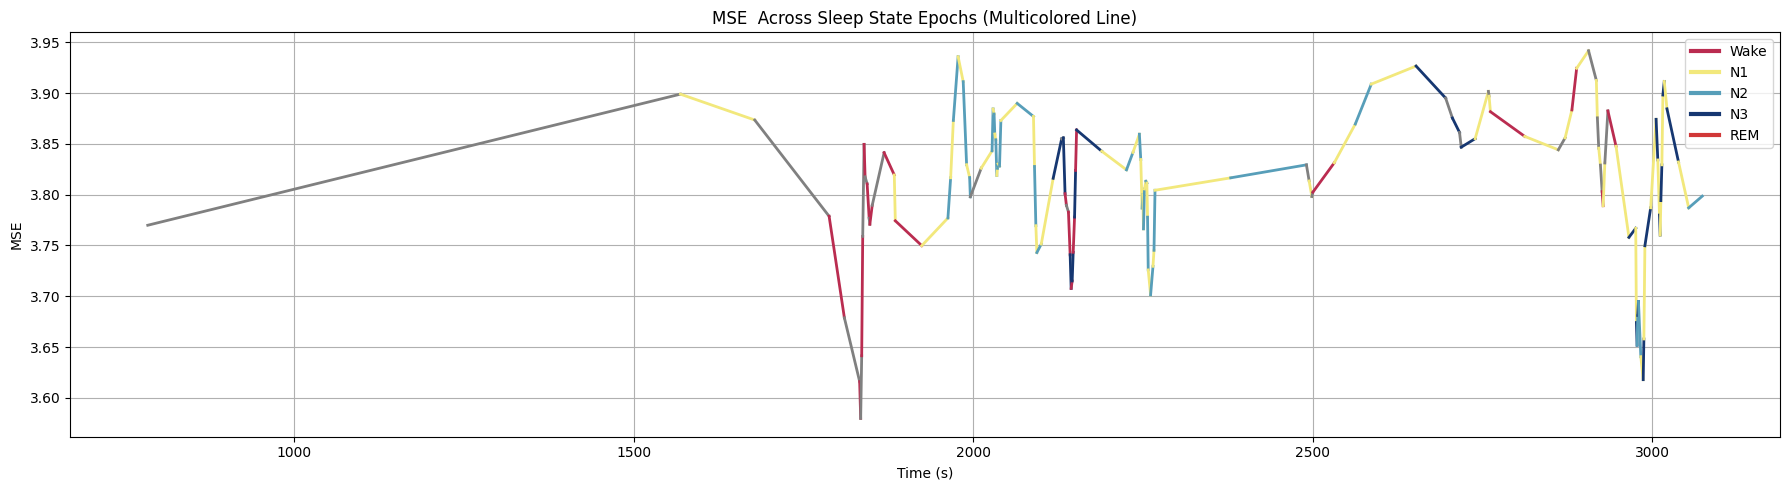

In [26]:
plt.figure(figsize=(18, 5))

window_length = 11 if len(mse_values_epoch) >= 11 else len(mse_values_epoch) | 1  # ensure it's odd
polyorder = 4

mse_smoothed_exponents = savgol_filter(mse_values_epoch, window_length=window_length, polyorder=polyorder)

# Plot each line segment with its state color
for i in range(len(epoch_times_mse) - 1):
    x = [epoch_times_mse[i], epoch_times_mse[i + 1]]
    y = [mse_smoothed_exponents[i], mse_smoothed_exponents[i + 1]]
    state = epoch_labels_mse[i]
    color = state_map.get(state, 'gray')
    plt.plot(x, y, color=color, linewidth=2)


plt.xlabel('Time (s)')
plt.ylabel('MSE')
plt.title('MSE  Across Sleep State Epochs (Multicolored Line)')
plt.grid(True)

# Legend for states
legend_elements = [plt.Line2D([0], [0], color=state_map[s], lw=3, label=state_names[s]) for s in state_map]

plt.legend(handles=legend_elements, loc='upper right')
plt.tight_layout()
plt.show()

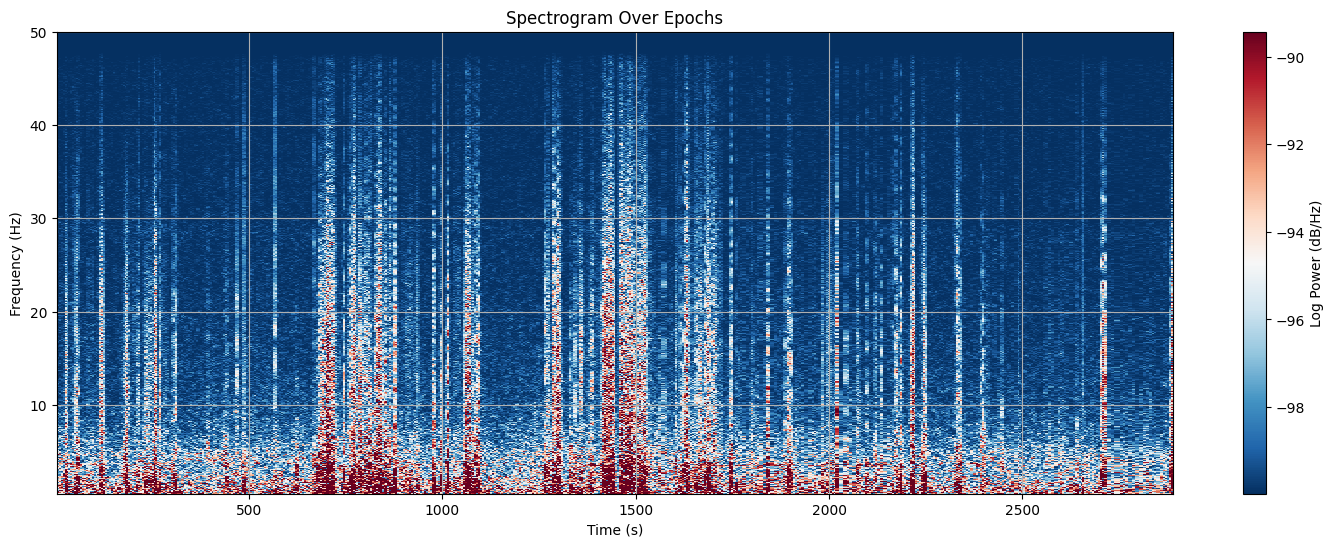

In [27]:
from scipy.signal import spectrogram

fmin, fmax = 0.5, 50
nperseg = int(10 * fs)
noverlap = nperseg // 2

# Get epochs
epochs = find_all_state_epochs(sleep_states)

# Init for concatenating results
spec_data = []
spec_times = []
spec_freqs = None
spec_colors = []

time_cursor = 0  # tracks where to place each epoch’s spectrogram

for start_sec, end_sec, state in epochs:
    start_sample = start_sec * fs
    end_sample = (end_sec + 1) * fs
    segment = lfp_PFC[start_sample:end_sample]

    # Skip too short segments
    if len(segment) < nperseg:
        continue

    f, t, Sxx = spectrogram(segment, fs=fs, nperseg=nperseg, noverlap=noverlap)

    # Filter frequencies
    freq_mask = (f >= fmin) & (f <= fmax)
    Sxx = Sxx[freq_mask, :]
    f = f[freq_mask]

    if spec_freqs is None:
        spec_freqs = f

    # Time correction to place each epoch properly on x-axis
    corrected_t = t + time_cursor
    spec_times.append(corrected_t)
    spec_data.append(Sxx)
    spec_colors.append(state)

    time_cursor += (len(segment) / fs)

# Concatenate
spec_data = np.concatenate(spec_data, axis=1)
spec_times = np.concatenate(spec_times)

# Convert to dB scale
Sxx_dB = 10 * np.log10(spec_data + 1e-10)

# Plot
plt.figure(figsize=(18, 6))
im = plt.pcolormesh(spec_times, spec_freqs, Sxx_dB, shading='auto', cmap='RdBu_r')
vmin, vmax = np.percentile(Sxx_dB, [10, 98])
im.set_clim(vmin, vmax)
plt.colorbar(label='Log Power (dB/Hz)')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.ylim(fmin, fmax)
plt.title('Spectrogram Over Epochs')
plt.grid()
plt.show()

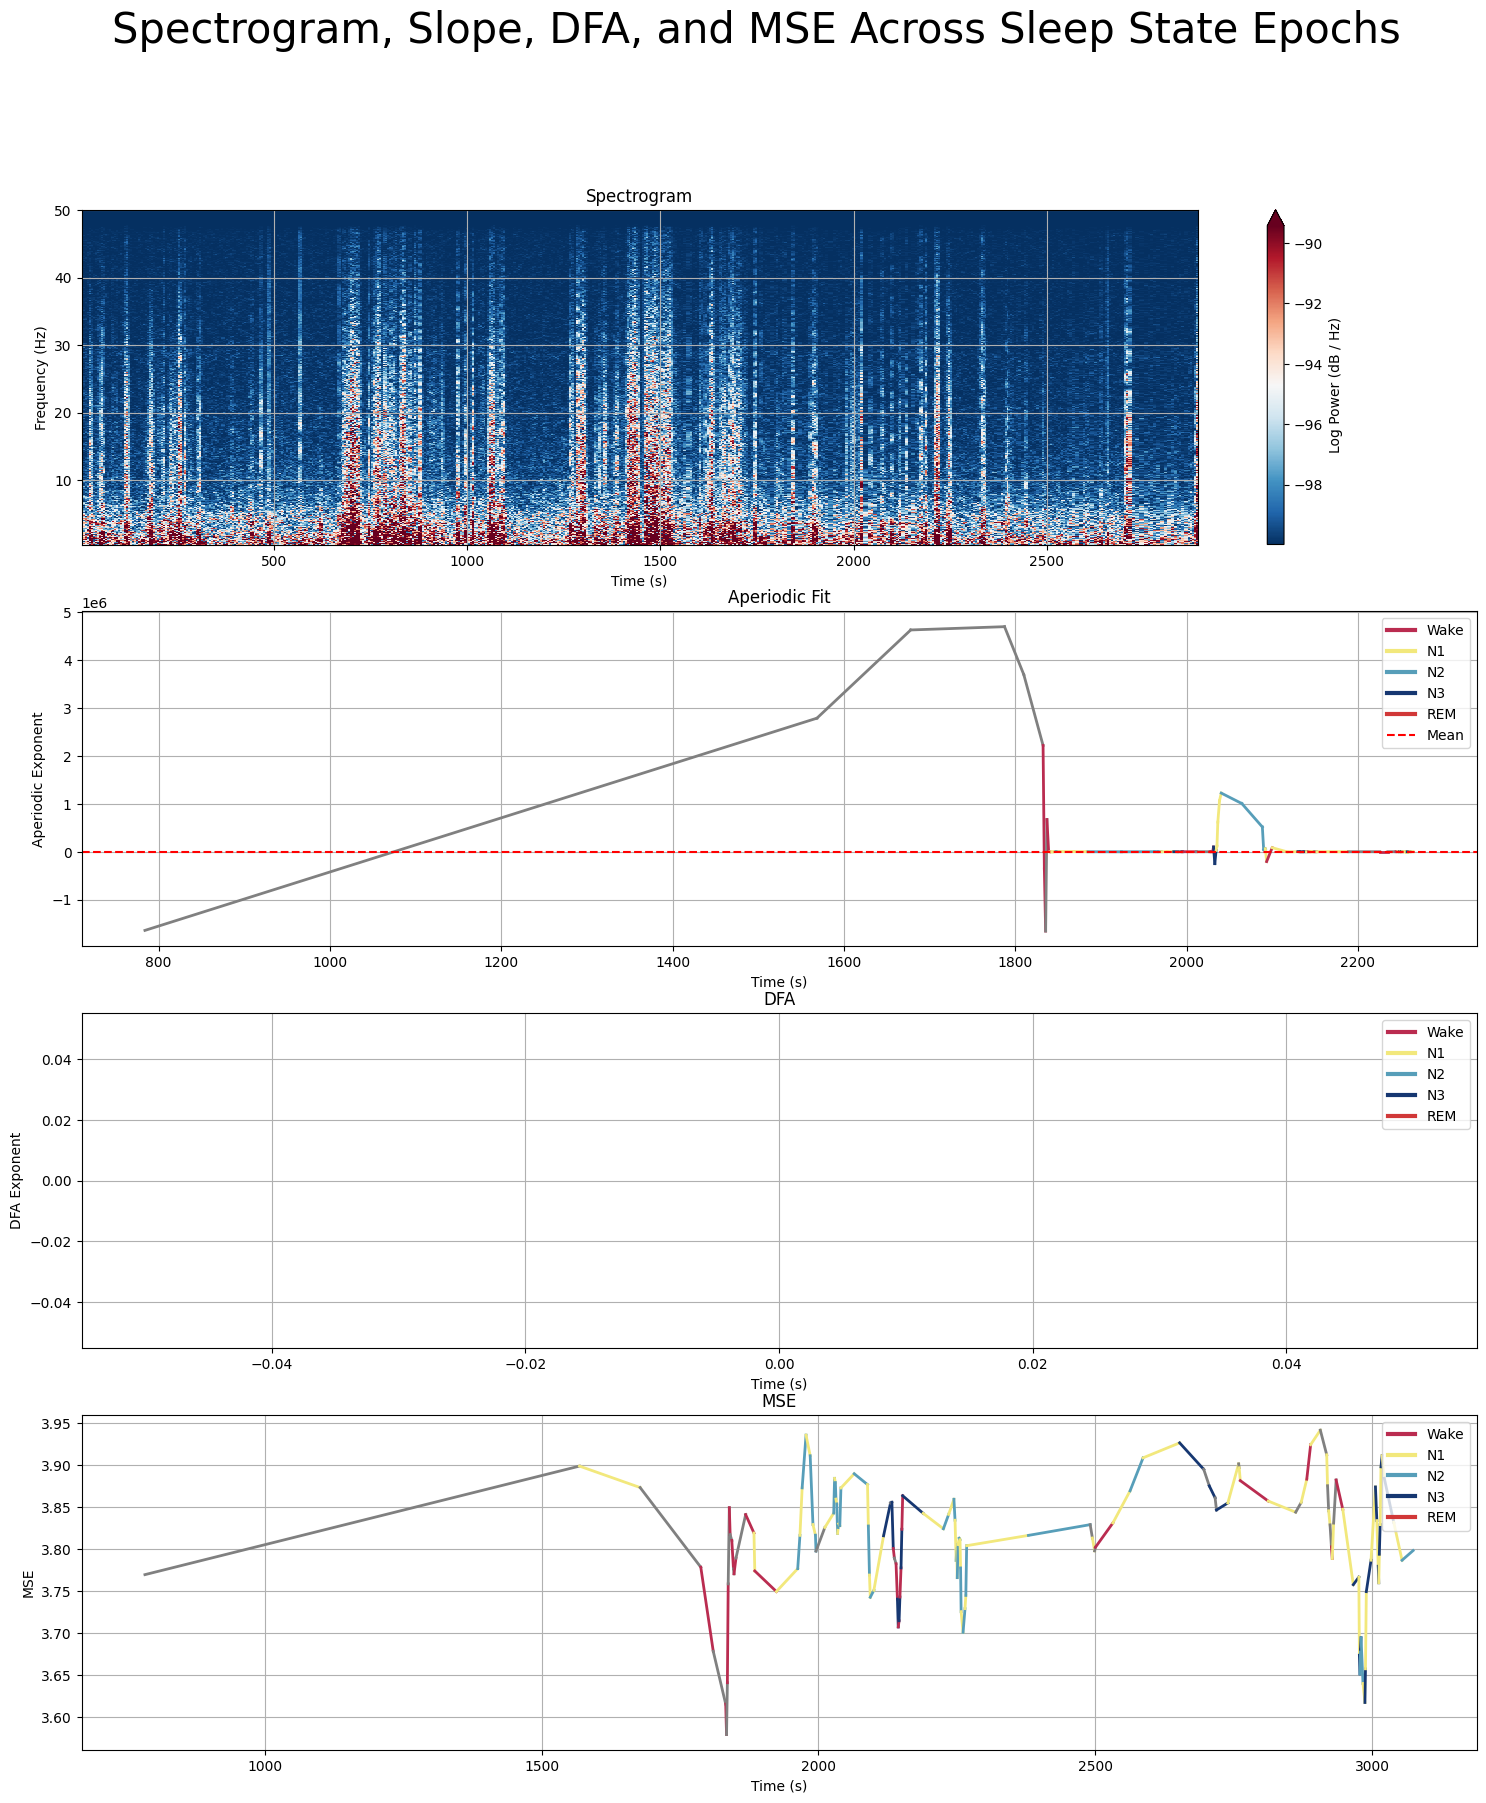

In [31]:
fig, axs = plt.subplots(4, 1, figsize=(18, 20))
fig.suptitle('Spectrogram, Slope, DFA, and MSE Across Sleep State Epochs', fontsize=30)

#SPECTROGRAM
im = axs[0].pcolormesh(spec_times, spec_freqs, Sxx_dB, shading='auto', cmap='RdBu_r')
vmin, vmax = np.percentile(Sxx_dB, [10, 98])
im.set_clim(vmin, vmax)
cbar = fig.colorbar(im, ax=axs[0], extend='max', label="Log Power (dB / Hz)")
axs[0].set_xlabel('Time (s)')
axs[0].set_ylabel('Frequency (Hz)')
axs[0].set_title('Spectrogram')
axs[0].grid()

# --- SLOPE ---
epoch_times_slope = epoch_times[:len(smoothed_exponents)]
for i in range(len(epoch_times_slope) - 1):
    x = [epoch_times_slope[i], epoch_times_slope[i + 1]]
    y = [smoothed_exponents[i], smoothed_exponents[i + 1]]
    state = state_labels[i]
    color = state_map.get(state, 'gray')
    axs[1].plot(x, y, color=color, linewidth=2)

axs[1].axhline(0, color='red', linestyle='--', label='Mean')

axs[1].set_xlabel('Time (s)')
axs[1].set_ylabel('Aperiodic Exponent')
axs[1].set_title('Aperiodic Fit')
axs[1].grid(True)

legend_elements = [plt.Line2D([0], [0], color=state_map[s], lw=3, label=state_names[s]) for s in state_map]
legend_elements.append(plt.Line2D([0], [0],  linestyle='--', color='red', label='Mean'))

axs[1].legend(handles=legend_elements, loc='upper right')

# --- DFA ---
epoch_times_dfa = epoch_times[:len(dfa_smoothed_exponents)]
for i in range(len(epoch_times_dfa) - 1):
    x = [epoch_times_dfa[i], epoch_times_dfa[i + 1]]
    y = [dfa_smoothed_exponents[i], dfa_smoothed_exponents[i + 1]]
    state = epoch_labels[i]
    color = state_map.get(state, 'gray')
    axs[2].plot(x, y, color=color, linewidth=2)

axs[2].set_xlabel('Time (s)')
axs[2].set_ylabel('DFA Exponent')
axs[2].set_title('DFA')
axs[2].grid(True)

legend_elements = [plt.Line2D([0], [0], color=state_map[s], lw=3, label=state_names[s]) for s in state_map]

axs[2].legend(handles=legend_elements, loc='upper right')

# --- MSE ---
epoch_times_mse = epoch_times_mse[:len(mse_smoothed_exponents)]
for i in range(len(epoch_times_mse) - 1):
    x = [epoch_times_mse[i], epoch_times_mse[i + 1]]
    y = [mse_smoothed_exponents[i], mse_smoothed_exponents[i + 1]]
    state = epoch_labels_mse[i]
    color = state_map.get(state, 'gray')
    axs[3].plot(x, y, color=color, linewidth=2)


axs[3].set_xlabel('Time (s)')
axs[3].set_ylabel('MSE')
axs[3].set_title('MSE')
axs[3].grid(True)

# Legend for states
legend_elements = [plt.Line2D([0], [0], color=state_map[s], lw=3, label=state_names[s]) for s in state_map]

axs[3].legend(handles=legend_elements, loc='upper right')
plt.savefig("spec_slope_dfa_mse.svg", format='svg')
plt.show()

# OS Basic: Results for windowing (4s windows)

In [29]:
fs_osb = 250
window_size = 4 * fs_osb
step_size = window_size  # In case we wanted overlap later.

## Aperiodic Fit

In [30]:
num_windows = len(lfp_OSB) // window_size
time_stamps = np.arange(num_windows) * 4

aperiodic_exponents = []

for i in range(num_windows):
    start, end = i * window_size, (i + 1) * window_size
    window_data = lfp_OSB[start:end]

    freqs, psd = welch(window_data, fs=fs_osb, nperseg=1024)

    mask = (freqs <= 100)
    freqs, psd = freqs[mask], psd[mask]

    fm = SpectralModel(min_peak_height=0.05, aperiodic_mode='knee', verbose=False)
    fm.fit(freqs, psd)

    aperiodic_exponents.append(fm.get_params('aperiodic')[1])

aperiodic_exponents = np.array(aperiodic_exponents)

# Thresholding to remove outliers
threshold_min = np.percentile(aperiodic_exponents, 2)
threshold_max = np.percentile(aperiodic_exponents, 98)
valid_indices = (aperiodic_exponents >= threshold_min) & (aperiodic_exponents <= threshold_max)

filtered_exponents = aperiodic_exponents[valid_indices]
filtered_timestamps = time_stamps[valid_indices]

#filtered_exponents_z = (filtered_exponents - np.mean(filtered_exponents)) / np.std(filtered_exponents)
window_length = 11 if len(filtered_exponents) >= 11 else len(filtered_exponents) | 1  # ensure it's odd
polyorder = 4

smoothed_exponents = savgol_filter(filtered_exponents, window_length=window_length, polyorder=polyorder)
normalized_exponents = 2 * ((smoothed_exponents - min(smoothed_exponents)) /(max(smoothed_exponents) - min(smoothed_exponents))) - 1

plt.figure(figsize=(18, 5))
plt.plot(filtered_timestamps, normalized_exponents, marker='.', linestyle='-', color=DarkBlue)
plt.xlabel('Time (s)')
plt.ylabel('Aperiodic Exponent')
plt.title('Normalized Aperiodic Fit Over Time (With Threshold) - OS Basic')
#plt.axhline(0, color='r', linestyle='--', label='Mean')
#plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

NameError: name 'lfp_OSB' is not defined

## DFA

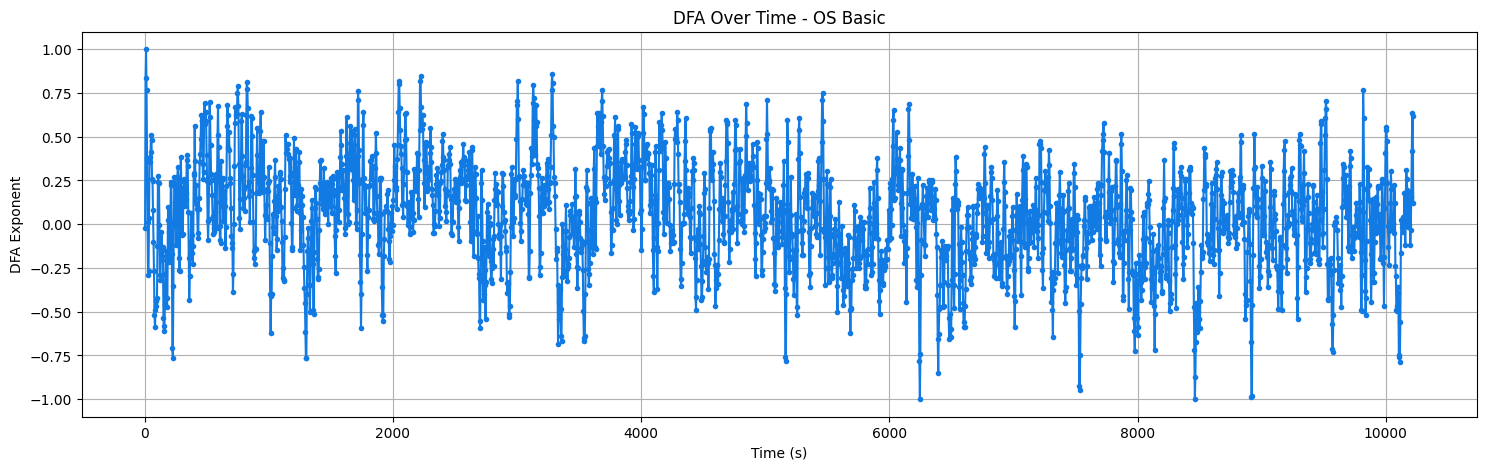

In [ ]:
num_windows = (len(lfp_OSB) - window_size) // step_size + 1

dfa_exponents = []
time_stamps = []

for i in range(num_windows):
    start = i * step_size
    end = start + window_size
    segment = lfp_OSB[start:end]

    _, _, exp_window = compute_fluctuations(segment, fs_osb, n_scales=10,
                                            min_scale=0.05, max_scale=4.0)

    dfa_exponents.append(exp_window)
    time_stamps.append((start + end) / 2 / fs_osb)

dfa_exponents = np.array(dfa_exponents)
window_length = 11 if len(dfa_exponents) >= 11 else len(dfa_exponents) | 1  # ensure it's odd
polyorder = 4

smoothed_dfa = savgol_filter(dfa_exponents, window_length=window_length, polyorder=polyorder)
normalized_dfa = 2 * ((smoothed_dfa - min(smoothed_dfa)) /(max(smoothed_dfa) - min(smoothed_dfa))) - 1
plt.figure(figsize=(18, 5))
plt.plot(time_stamps, normalized_dfa, marker='.', linestyle='-', color=Blue)
plt.xlabel('Time (s)')
plt.ylabel('DFA Exponent')
plt.title('DFA Over Time - OS Basic')
plt.grid()
plt.show()

## MSE

 . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .

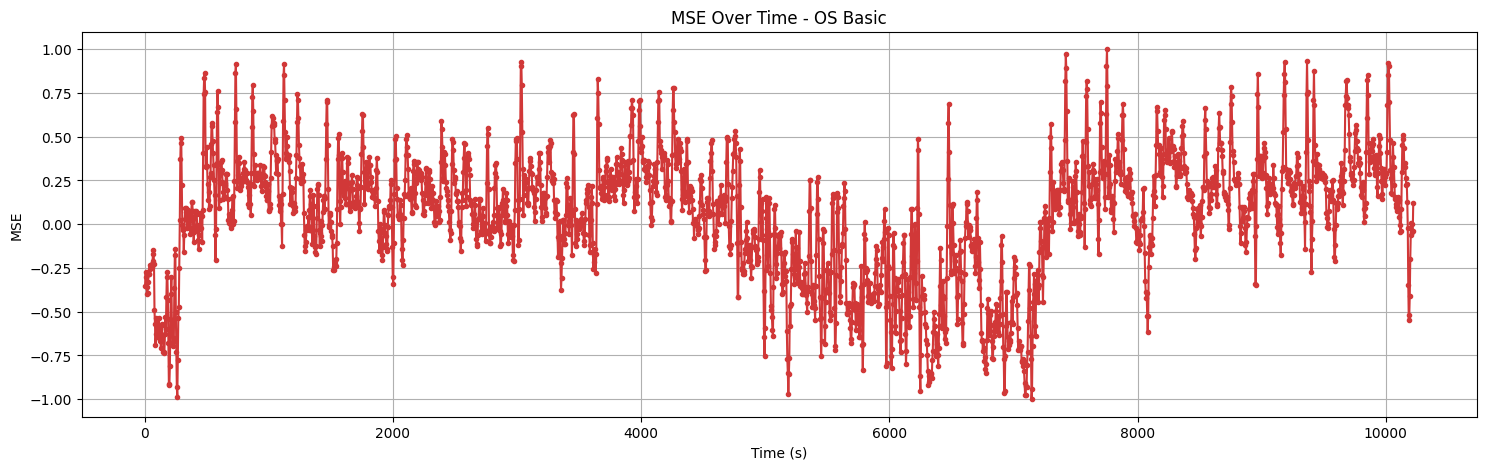

In [ ]:
Mobj = EH.MSobject('IncrEn', m=2, R=3, Norm=True)

num_windows = (len(lfp_OSB) - window_size) // step_size + 1

mse_values = []
time_stamps_mse = []

for i in range(num_windows):
    start = i * step_size
    end = start + window_size
    segment = lfp_OSB[start:end]

    MSx, _ = EH.MSEn(segment, Mobj, Scales=2, Methodx='modified')

    mse_values.append(np.mean(MSx))
    time_stamps_mse.append((start + end) / 2 / fs_osb)

mse_values = np.array(mse_values)
time_stamps_mse = np.array(time_stamps_mse)
window_length = 11 if len(mse_values) >= 11 else len(mse_values) | 1  # ensure it's odd
polyorder = 4

smoothed_mse = savgol_filter(mse_values, window_length=window_length, polyorder=polyorder)
normalized_mse = 2 * ((smoothed_mse - min(smoothed_mse)) /(max(smoothed_mse) - min(smoothed_mse))) - 1

plt.figure(figsize=(18, 5))
plt.plot(time_stamps_mse, normalized_mse, marker='.', linestyle='-', color=Red)
plt.xlabel('Time (s)')
plt.ylabel('MSE')
plt.title('MSE Over Time - OS Basic')
plt.grid()
plt.show()

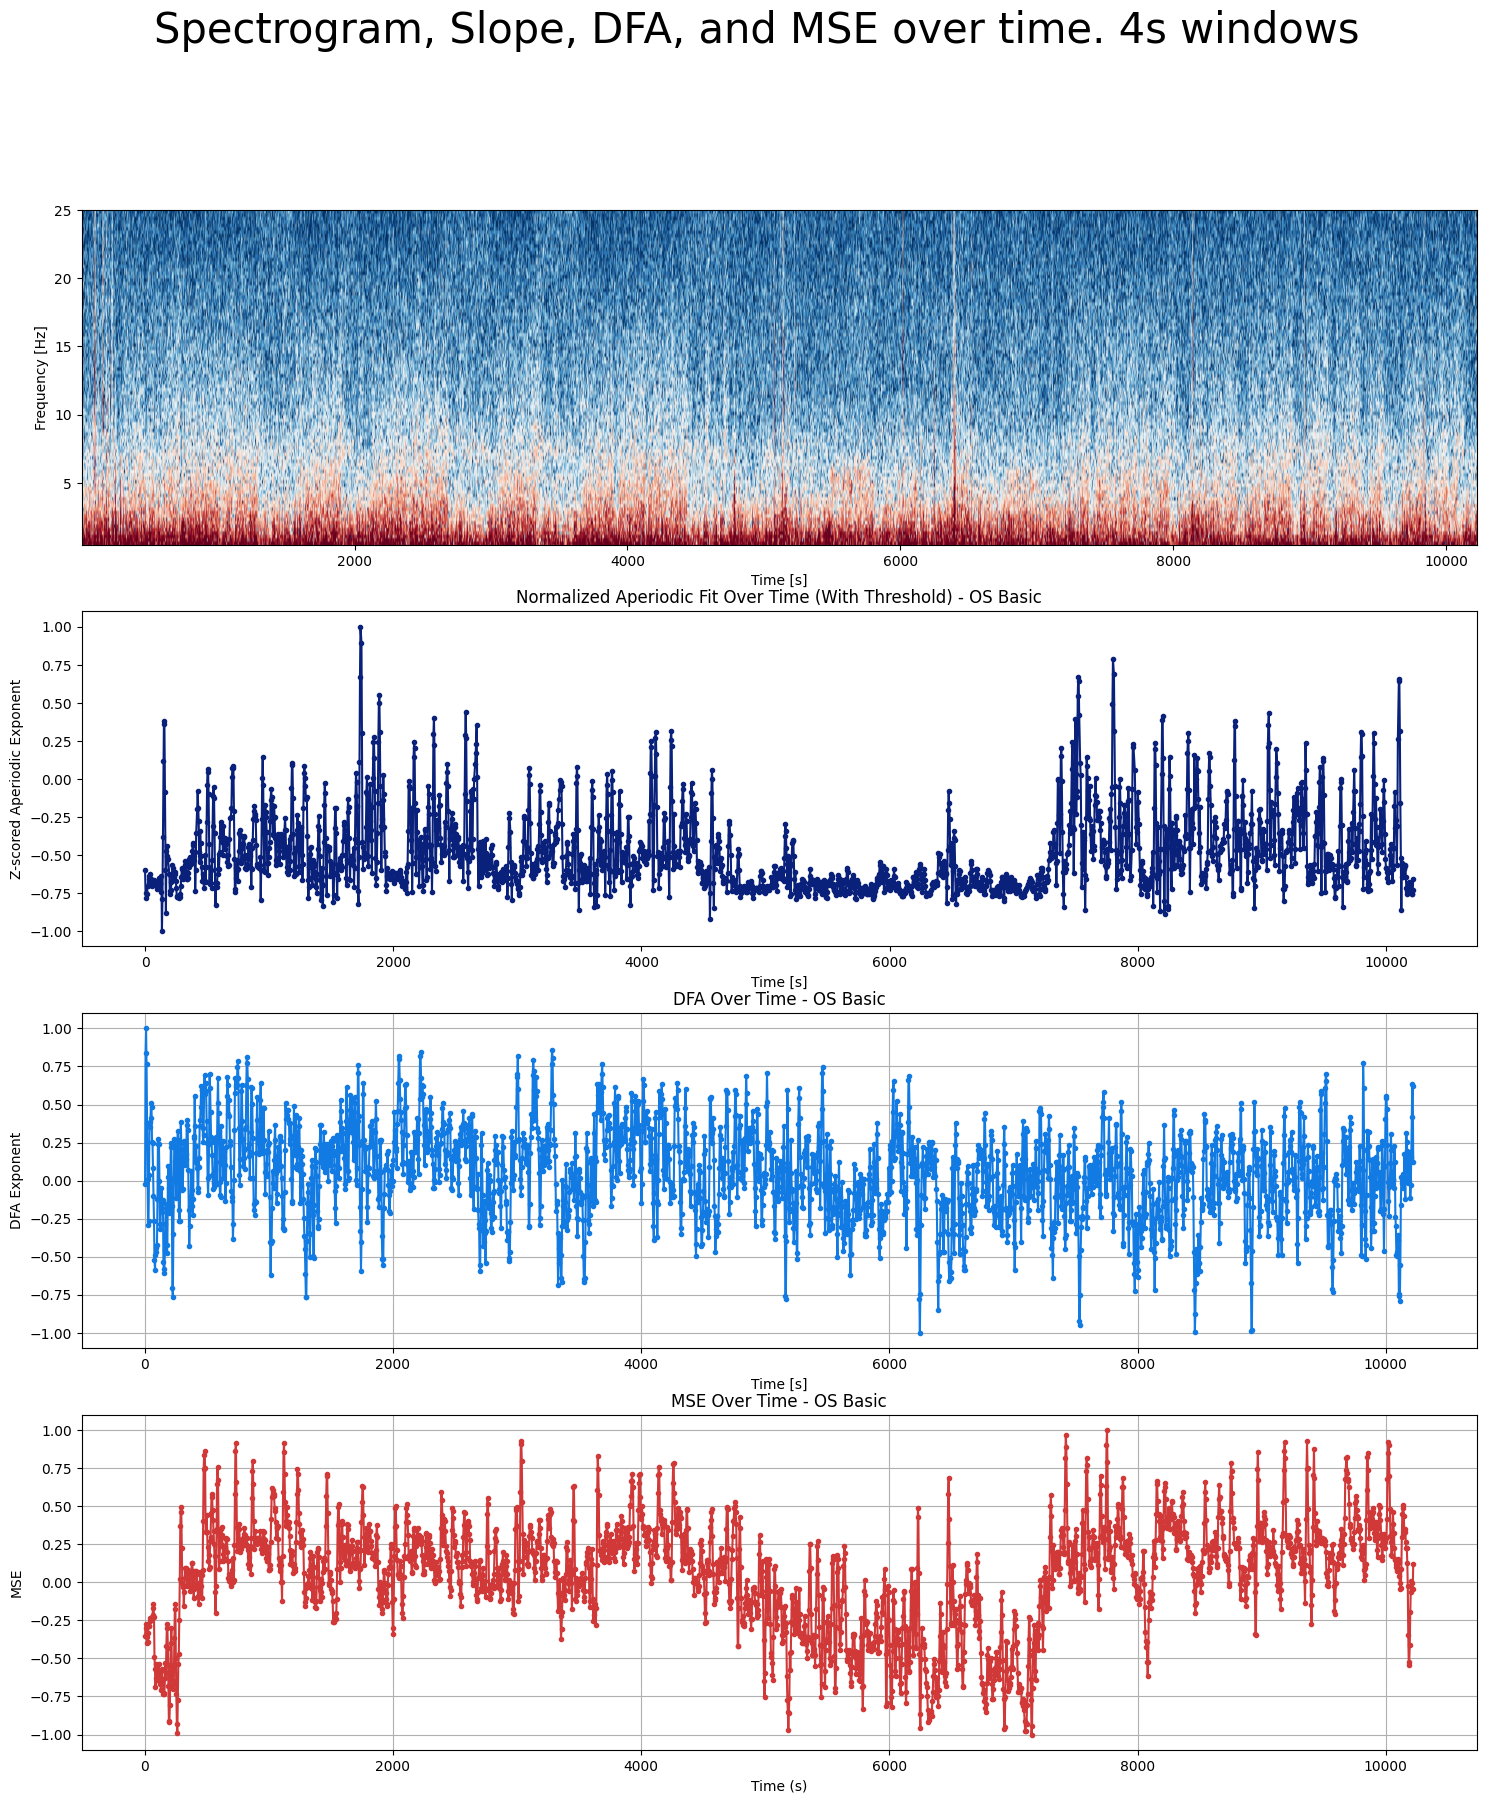

In [ ]:
# SPECTROGRAM
nperseg = int(4 * fs_osb)      # Window Size
fmin, fmax = 0.5, 25

# Create Plot
fig, axs = plt.subplots(4, 1, figsize=(18, 20))
fig.suptitle('Spectrogram, Slope, DFA, and MSE over time. 4s windows - OS Basic', fontsize=30)

Pxx, freqs, bins, im = axs[0].specgram(lfp_OSB, NFFT=nperseg, Fs=fs_osb, cmap="RdBu_r", scale="dB")

# Frequency (0.5 Hz ≤ f ≤ 25 Hz)
freq_mask = (freqs >= fmin) & (freqs <= fmax)
freqs = freqs[freq_mask]
Pxx = Pxx[freq_mask, :]

vmin, vmax = np.percentile(10 * np.log10(Pxx + 1e-10), [10, 98])
im.set_clim(vmin, vmax)

axs[0].set_ylabel("Frequency [Hz]")
axs[0].set_xlabel("Time [s]")
#cbar = fig.colorbar(im, ax=axs[0], extend='max', label="Log Power (dB / Hz)")
axs[0].set_ylim(fmin, fmax)


# SLOPE
axs[1].plot(filtered_timestamps, normalized_exponents, marker='.', linestyle='-', color=DarkBlue)
axs[1].set_xlabel('Time [s]')
axs[1].set_ylabel('Z-scored Aperiodic Exponent')
axs[1].set_title('Normalized Aperiodic Fit Over Time (With Threshold) - OS Basic')
#axs[1].axhline(0, color='r', linestyle='--', label='Mean')
#axs[1].legend()

# DFA
axs[2].plot(time_stamps, normalized_dfa, marker='.', linestyle='-', color=Blue)
axs[2].set_xlabel('Time [s]')
axs[2].set_ylabel('DFA Exponent')
axs[2].set_title('DFA Over Time - OS Basic')
axs[2].grid()

axs[3].plot(time_stamps_mse, normalized_mse, marker='.', linestyle='-', color=Red)
axs[3].set_xlabel('Time (s)')
axs[3].set_ylabel('MSE')
axs[3].set_title('MSE Over Time - OS Basic')
axs[3].grid()

plt.show()